<a href="https://colab.research.google.com/github/AbdulkaderKharrat/AbdulkaderKharrat/blob/main/taitanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/titanic_train (2).csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.duplicated().sum()

0

In [ ]:
df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


In [ ]:
len(df.Ticket.unique())

681

In [ ]:
### Notes

# for DS
# missing value
# 1) Age 714/891 -> 891-714 missing value
# 2) Cabin 204/891 -> 891-204 missing value
# 3) Embarked 889/891 -> 891-889 missing value

# There no duplicated values

# Features You can drop: PassengerId, Name, Ticket

In [ ]:
numerical_df = df.select_dtypes(include=['number'])
numerical_df = numerical_df [['Age','Fare']]
numerical_df.head(1)

,Age,Fare
0,22.0,7.25


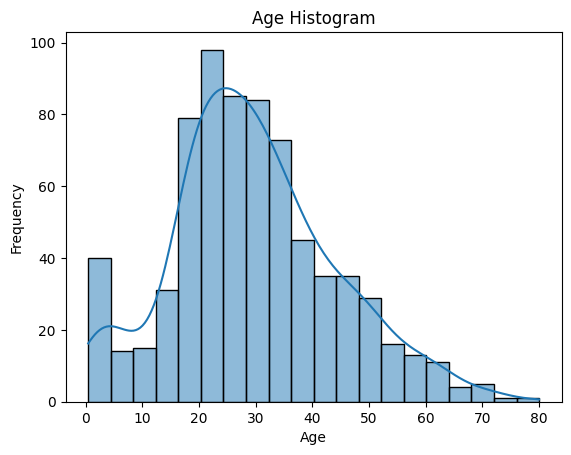

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['Age'], bins=20, kde=True)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Histogram')
plt.show()

<Axes: xlabel='Age'>

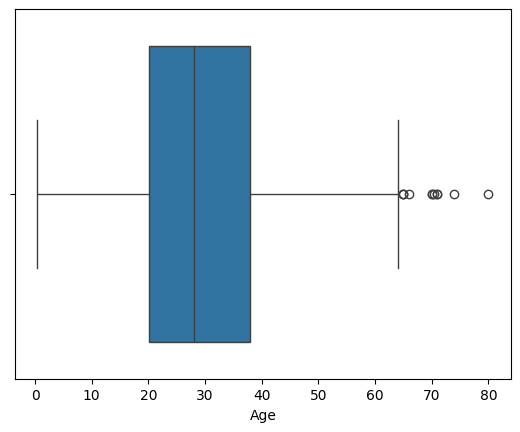

In [ ]:
sns.boxplot(x=df['Age'])

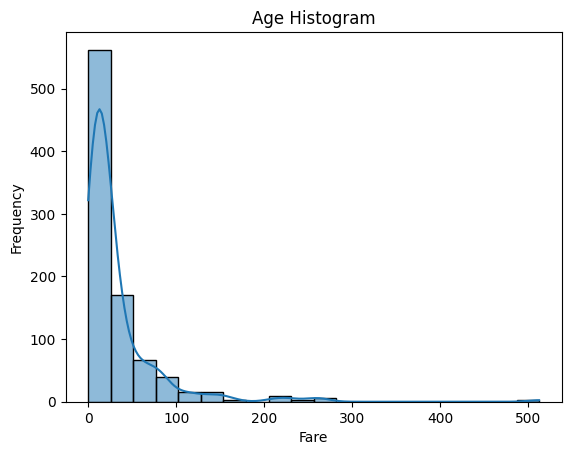

In [ ]:
# for Fare
sns.histplot(df['Fare'], bins=20, kde=True)
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.title('Age Histogram')
plt.show()

<Axes: xlabel='Fare'>

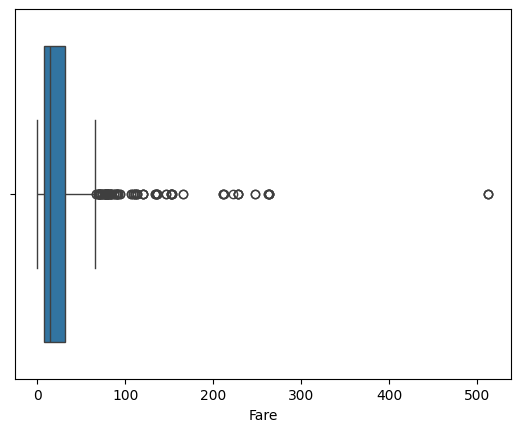

In [ ]:
sns.boxplot(x=df['Fare'])

In [ ]:
# corr
correlation = df['Age'].corr(df['Fare'])

In [ ]:
correlation

0.0960666917690389

In [ ]:
# Numarical DA
# Age feature: the Age has some problem, its have ages less than 1
# Age feature: there outliers more than 60
# Fare feature: its skewd to the right
# Fare feature: there outliers

In [ ]:
# categorical
categorical_df = df.select_dtypes(include=['object', 'category'])
categorical_df["SibSp"] = df["SibSp"]
categorical_df["Parch"] = df["Parch"]
categorical_df["Pclass"] = df["Pclass"]
categorical_df = categorical_df[["Sex","Cabin","Embarked","SibSp","Parch","Pclass"]]
categorical_df

,Sex,Cabin,Embarked,SibSp,Parch,Pclass
0,male,NaN,S,1,0,3
1,female,C85,C,1,0,1
2,female,NaN,S,0,0,3
3,female,C123,S,1,0,1
4,male,NaN,S,0,0,3
...,...,...,...,...,...,...
886,male,NaN,S,0,0,2
887,female,B42,S,0,0,1
888,female,NaN,S,1,2,3
889,male,C148,C,0,0,1


In [ ]:
for column in categorical_df.columns:
    print(f"Value counts for {column}:")
    print(categorical_df[column].value_counts())
    print('---' * 10)

Value counts for Sex:
Sex
male      577
female    314
Name: count, dtype: int64
------------------------------
Value counts for Cabin:
Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: count, Length: 147, dtype: int64
------------------------------
Value counts for Embarked:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
------------------------------
Value counts for SibSp:
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
------------------------------
Value counts for Parch:
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
------------------------------
Value counts for Pclass:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
------------------------------


In [ ]:
len(categorical_df['Cabin'].unique())

148

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# categorical result
#  Parch and SibSp -> biased for 0

In [ ]:
# Create a crosstab to get the counts of each combination
import plotly.express as px
ct = pd.crosstab(df['Pclass'], df['Survived'])

# Reset the index to make 'Pclass' a regular column
ct.reset_index(inplace=True)

# Melt the DataFrame to make it suitable for plotting
melted_ct = pd.melt(ct, id_vars='Pclass', value_vars=[0, 1],
                    var_name='Survived', value_name='Count')

# Create the interactive bar plot
fig = px.bar(melted_ct, x='Pclass', y='Count',
             color='Survived', title='Survival by Passenger Class',
             labels={'Pclass': 'Passenger Class', 'Count': 'Number of Passengers'},
             text='Count')

# Show the plot
fig.show()
fig.write_html("Survival_by_Passenger_Class.html")

In [ ]:
ct = pd.crosstab(df['Sex'], df['Survived'])

# Reset the index to make 'Sex' a regular column
ct.reset_index(inplace=True)

# Melt the DataFrame to make it suitable for plotting
melted_ct = pd.melt(ct, id_vars='Sex', value_vars=[0, 1],
                    var_name='Survived', value_name='Count')

# Create the interactive bar plot
fig = px.bar(melted_ct, x='Sex', y='Count',
             color='Survived', title='Survival by Sex',
             labels={'Sex': 'Sex', 'Count': 'Number of Passengers'},
             text='Count')

# Save the plot to an HTML file
fig.write_html("Survival_by_Sex.html")

# Show the plot
fig.show()

In [ ]:
fig = px.histogram(df, x="Age", color="Survived",
                   barmode="overlay", nbins=30,
                   labels={'Age': 'Age', 'count': 'Number of Passengers'},
                   title='Survival by Age')

# Save the plot to an HTML file
fig.write_html("Survival_by_Age.html")

# Show the plot
fig.show()

In [ ]:
### Results:
# missing value
# 1) Age 714/891 -> 891-714 missing value
# 2) Cabin 204/891 -> 891-204 missing value
# 3) Embarked 889/891 -> 891-889 missing value

# There no duplicated values

# Features You can drop: PassengerId, Name, Ticket

# Numarical DA
# Age feature: the Age has some problem, its have ages less than 1
# Age feature: there outliers more than 60
# Fare feature: its skewd to the right
# Fare feature: there outliers

# categorical result
#  Parch and SibSp -> biased for 0

In [ ]:
# DS -> Supervised | Classification | Confusion metrics |

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
